
## Getting Started: Setting up Workspace and Data Overview

### Accessing MIMIC-IV Dataset

MIMIC-IV is a deidentified EHR dataset sourced from BIDMC Hospital. To gain access to MIMIC-IV, follow these steps

1. Register [here](https://physionet.org/register/) to create a physionet account and become a credential user.
2. Complete the training listed [here](https://physionet.org/content/mimiciv/view-required-training/3.1/) and submit the trainings [here](https://physionet.org/settings/training/).
3. Sign the Data User Agreement [here](https://physionet.org/login/?next=/sign-dua/mimiciv/3.1/).

Once your access is approved, you will receive a notification through your registered email.

## Setting up your Compute Environment


1. Create a workspace to download and process MIMIC-IV data.
2. Download all the tutorial notebooks into the workspace.
3. Create a virtual environment and install the required Python libraries.
4. Download the MIMIC data into the workspace.

For this tutorial, the file structure is organized as below. For Unix-based systems, we provide a setup script that will automatically create the necessary directories and prepare the environment.

```plaintext
EHR_TUTORIAL_WORKSPACE/
├── processed_data/                # Outputs after cleaning & standardization
│
├── raw_data/                      # Original downloaded MIMIC data
│   ├── note_data/
│   │   └── physionet.org/
│   │       └── files/
│   │           └── mimic-iv-note/
│   │               └── 2.2/
│   │                   └── note/
│   │                       └── *.csv.gz
│   │
│   └── structured_data/
│       └── physionet.org/
│           └── files/
│               └── mimiciv/
│                   └── 3.1/
│                       ├── hosp/
│                       │   └── *.csv.gz
│                       └── icu/
│                           └── *.csv.gz
│
└── scripts/                       # Tutorial ipynb notebooks & mapping files
    └── EHR-Processing-Tutorial-main/
        ├── meta_files/  
        └── Rollup_Mappings/
            

```



The following script can be run on Unix based systems to setup the workspace. 

```bash
#!/bin/bash

# Set the location variable to the path where you want to create the MIMIC workspace
LOCATION="/path/to/your/workspace"

# If you would like to download and work in your home directory, you can update above to LOCATION="$HOME"

# Check if the workspace folder already exists
if [ -d "${LOCATION}/EHR_TUTORIAL_WORKSPACE" ]; then
  echo "EHR_TUTORIAL_WORKSPACE folder already exists here ${LOCATION}/EHR_TUTORIAL_WORKSPACE"
  exit 0
fi

# Create the workspace directory
mkdir "${LOCATION}/EHR_TUTORIAL_WORKSPACE"
echo "Workspace has been created here ${LOCATION}/EHR_TUTORIAL_WORKSPACE"

# Create the workspace subdirectories
echo "Creating raw_data, processed_data, and scripts subdirectories"
mkdir -p "${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/structured_data" \
         "${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/note_data" \
         "${LOCATION}/EHR_TUTORIAL_WORKSPACE/processed_data" \
         "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts"
echo "Workspace has been set up here ${LOCATION}/EHR_TUTORIAL_WORKSPACE"

# Download and extract MIMIC Data Prep scripts from GitHub
echo "Downloading and extracting MIMIC Data Prep scripts from GitHub..."
wget https://github.com/apvidul/EHR-Processing-Tutorial/archive/refs/heads/main.zip -O mimic-data-prep.zip
unzip -q mimic-data-prep.zip -d "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts"
mv "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts/EHR-Processing-Tutorial-main/"* "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts/"

# Cleanup unnecessary files and folders
rm -rf mimic-data-prep.zip "${LOCATION}/EHR_TUTORIAL_WORKSPACE/scripts/EHR-Processing-Tutorial-main"

echo "Creating the Conda environment ehr_tutorial"
conda create --yes --name ehr_tutorial pandas wordcloud jupyter tqdm matplotlib

# Downloading the structured MIMIC data into raw_data/structured_data
wget -r -N -c -np --user ${PHYSIONET_USERNAME} --password ${PHYSIONET_PASSWORD} \
  https://physionet.org/files/mimiciv/3.1/ \
  -P ${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/structured_data

# Downloading the note data into raw_data/note_data
wget -r -N -c -np --user ${PHYSIONET_USERNAME} --password ${PHYSIONET_PASSWORD} \
  https://physionet.org/files/mimic-iv-note/2.2/ \
  -P ${LOCATION}/EHR_TUTORIAL_WORKSPACE/raw_data/note_data

```



Once MIMIC is downloaded, you are ready to work on this notebook. The data is currently in zipped format, you can go ahead and run the following block to unzip.

In [ ]:
import os

# Specifice the tutorial workspace location below
LOCATION = "/n/scratch/users/v/va67/EHR_TUTORIAL_WORKSPACE"

# Build the path to the .gz files using os.path.join
hosp_gz_files_path = os.path.join(LOCATION, "raw_data", "physionet.org", "files", "mimiciv", "3.1", "hosp")

# Run the gunzip command directly in the IPython notebook
print("Please wait, files are being unzipped")
!gunzip {hosp_gz_files_path}/*.gz
print(f"All .gz files in {hosp_gz_files_path} have been unzipped.\n")

note_gz_files_path = os.path.join(LOCATION, "raw_data", "nlp", "physionet.org", "files", "mimic-iv-note", "2.2", "note")
!gunzip {note_gz_files_path}/*.gz

print(f"All .gz files in {note_gz_files_path} have been unzipped.\n")

## EHR Data Overview

After gaining access, it is essential to develop a thorough understanding of the EHR data to assemble the elements of interest and create a dataset aligned with the research objectives. This typically involves answering the following questions:

1. **What data is available, and where is it stored?**
2. **Which data elements are relevant, and how are they defined?**
3. **How is the data organized and linked across files and tables?**

These questions are typically addressed by consulting institution specific EHR documentation or the warehouse data manager. For MIMIC-IV, comprehensive documentation is available on the project website [here](https://mimic.mit.edu/docs/iv/).

For users new to EHR data, we highly recommend watching the MIMIC data tutorial [here](https://mimic.mit.edu/docs/iv/tutorials/video/).


#### What data is available and where is it stored?
Electronic Health Record (EHR) data can take many forms. For example, billing information and vital signs are typically recorded as tabular data, clinical notes are typically in free text format, ECG recordings generate waveform data, and procedures such as X-rays or CT scans generate image data. These data originate from various systems within the hospital and contain a wealth of information. Today, several frameworks facilitate clinical research using EHR data such as the [i2b2](https://community.i2b2.org/wiki/display/BUN/2.+Quick+Start+Guide) framework from MGB and Harvard and [VINCI](https://www.research.va.gov/programs/vinci/), maintained by Veterans Affairs, which provide both data and analytical tools to support research and analysis.

EHR data is typically stored in databases. In this tutorial, we will be working with MIMIC data stored as flat files. MIMIC-IV data comes in “modules” based on the source of data generation. Following are the five modules currently made available:

- [hosp](https://mimic.mit.edu/docs/iv/modules/hosp/) - Hospital-level data for patients, including labs, microbiology, and electronic medication administration records.  
- [icu](https://mimic.mit.edu/docs/iv/modules/icu/) - ICU-level data, including event tables (e.g., chart events) identical in structure to MIMIC-III.  
- [ed](https://mimic.mit.edu/docs/iv/modules/ed/) - Data from the emergency department.  
- [cxr](https://mimic.mit.edu/docs/iv/modules/cxr/) - Lookup tables and metadata from MIMIC-CXR, enabling linkage to MIMIC-IV.  
- [note](https://physionet.org/content/mimic-iv-note/2.2/) - De-identified free-text clinical notes.  

Below is a brief summary of the date contained in these modules

| Data type            | Data contents                          | Available at | Major tables / files                                   | Primary timestamps            |
|----------------------|--------------------------------------------|--------------------------|----------------------------------------------------------|---------------------------------|
| Diagnoses            | ICD-9/10 diagnosis codes per admission     | MIMIC-IV (hosp)          | `diagnoses_icd`, `d_icd_diagnoses`                       | Admission window (`admittime`, `dischtime`) |
| Procedures           | ICD-9/10-PCS, CPT/HCPCS events             | MIMIC-IV (hosp)          | `procedures_icd`, `hcpcsevents`, `d_icd_procedures`, `d_hcpcs` | Admission window; event dates (if present) |
| Medications          | Orders & administrations                   | MIMIC-IV (hosp)          | `prescriptions`, `emar`, `emar_detail`                   | `starttime`, `stoptime`, `charttime`        |
| Laboratory results   | Results + units                            | MIMIC-IV (hosp)          | `labevents`, `d_labitems`                                | `charttime`                      |
| Microbiology         | Cultures, organisms, sensitivities         | MIMIC-IV (hosp)          | `microbiologyevents`                                     | `charttime` / event time         |
| ICU flowsheets       | Vitals, assessments, outputs               | MIMIC-IV (icu)           | `chartevents`, `outputevents`, `icustays`, `d_items`     | `charttime`                      |
| Clinical notes       | Discharge, radiology, etc. (text)          | MIMIC-IV-Note            | `note`                                                   | `charttime` (or note time)       |
| Chest X-ray images   | DICOM/JPG images + study/series metadata   | MIMIC-CXR                | Image files + metadata CSVs                              | Study time / acquisition time    |
| ECG waveforms        | 10-sec, 12-lead diagnostic ECG waveforms   | MIMIC-IV-ECG             | WFDB waveform files + metadata                           | Acquisition time                 |
| ED stays (optional)  | Triage, meds, vitals during ED encounter   | MIMIC-IV-ED              | `edstays`, `triage`, `vitalsign`                         | ED times (arrival, discharge, etc.) |

For our tutorial, we will be working with MIMIC-IV `hosp` and `note` modules.

#### Which data elements are relevant, and how are they defined?

There are certain key data elements that are foundational for most EHR analyses.



| Key data element   | Description                                             | Examples in MIMIC-IV                                                                                 |
|--------------------|---------------------------------------------------------|-------------------------------------------------------------------------------------------------------|
| Unique Patient ID  | Patient identifier used across all tables and encounters| `subject_id`                                                                                          |
| Event              | A clinical record that something happened/was recorded  | Diagnoses (`diagnoses_icd`); Meds (`prescriptions`); Labs (`labevents`); Procedures (`procedures_icd`, `hcpcsevents`) |
| Time               | When the event occurred or was recorded                 | Event times (`charttime`, `starttime`, `stoptime`); admission window (`admittime`, `dischtime`) from `admissions`      |


The hosp module consists of  all data acquired from the hospital wide electronic health record. This includes patient information, lab measurements, microbiology, medication administered, and billed diagnoses. More information on tables in this module can be read on MIMIC IV documentation [here](https://mimic.mit.edu/docs/iv/modules/hosp/). Depending on your research needs, multiple tables may be relevant. Below, we list the tables we will be using in this tutorial.

| Type           | Table                | Purpose / contents                                                    | Key element(s) provided                | Primary code fields              | Primary time field(s) or anchor             | Typical join keys                 | Notes                                   |
|-------------------|----------------------|------------------------------------------------------------------------|----------------------------------------|----------------------------------|---------------------------------------------|-----------------------------------|-----------------------------------------|
| Data Dictionary   | `d_hcpcs`            | CPT/HCPCS code definitions                                            | Codes                                  | `hcpcs_cd`                       | —                                           | Link to `hcpcsevents.hcpcs_cd`    |                                         |
| Data Dictionary   | `d_icd_diagnoses`    | ICD-9/10 diagnosis code definitions                                   | Codes                                  | `icd_code`, `icd_version`       | —                                           | Link to `diagnoses_icd`           |                                         |
| Data Dictionary   | `d_icd_procedures`   | ICD-9/10 procedure code definitions                                   | Codes                                  | `icd_code`, `icd_version`       | —                                           | Link to `procedures_icd`          |                                         |
| Data Dictionary   | `d_labitems`         | Lab item dictionary (labels, categories, units metadata)              | Codes                                  | `itemid`                         | —                                           | Link to `labevents.itemid`        |                                         |
| Event Table       | `diagnoses_icd`      | Billed ICD diagnosis codes per hospitalization                        | Patient ID · Event · Codes             | `icd_code`, `icd_version`       | **Admission window** (`admittime`→`dischtime`) | `subject_id`, `hadm_id`           | No event timestamp in table             |
| Event Table       | `prescriptions`      | Medication orders                                                      | Patient ID · Event · **Time**          | Local drug fields / `ndc` (opt.) | `starttime`, `stoptime`                      | `subject_id`, `hadm_id`           | Map to RxNorm downstream if needed      |
| Event Table       | `labevents`          | Laboratory measurements (values + units)                              | Patient ID · Event · **Time** · Codes  | `itemid`                         | `charttime`                                  | `subject_id`, `hadm_id` (often)   | Values in `valuenum`, units in `valueuom` |
| Event Table       | `hcpcsevents`        | CPT/HCPCS billed events during hospitalization                        | Patient ID · Event · **Time** · Codes  | `hcpcs_cd`                       | `chartdate`                                  | `subject_id`, `hadm_id`           | (Typo fix: table is **hcpcsevents**)     |
| Event Table       | `procedures_icd`     | ICD-9/10-PCS billed procedures                                        | Patient ID · Event · Codes             | `icd_code`, `icd_version`       | **Admission window** (`admittime`→`dischtime`) | `subject_id`, `hadm_id`           | No event timestamp in table             |
| Patient Metadata  | `admissions`         | Admission episodes (in/out times, service, outcomes)                  | Patient ID · **Time**                  | —                                | `admittime`, `dischtime` (± `deathtime`)     | `subject_id`, `hadm_id`           | Use as time anchor for Dx/Proc tables    |
| Patient Metadata  | `transfers`          | Unit/ward movements within the hospital                               | Patient ID · **Time**                  | —                                | `intime`, `outtime`                           | `subject_id`, `hadm_id`           | Useful for location-aware analyses       |
| Patient Metadata  | `patients`           | Demographics and anchor fields                                        | Patient ID                              | —                                | (Optional) date of death                      | `subject_id`                      | No codes; demographics only              |




#### How is the data organized and linked across files and tables?

In EHR data, information can be spread across multiple tables or datasets. You will need to link data from different tables to create comprehensive dataset depending on your research needs. One of the key aspects for linking data is identifiers. The following are three major identifiers are used in MIMIC data. 

- **`SUBJECT_ID`**: This is a patient level identifier. The patients tables contains demographics for each unique patient
- **`HADM_ID`**: This is a hospital level identifier provided in the hosp module. Each unique hospital admission for a patient gets a unique id.
- **`STAY_ID`**: All ICU admissions within 24 hours of each other are grouped and assigned an identifier.

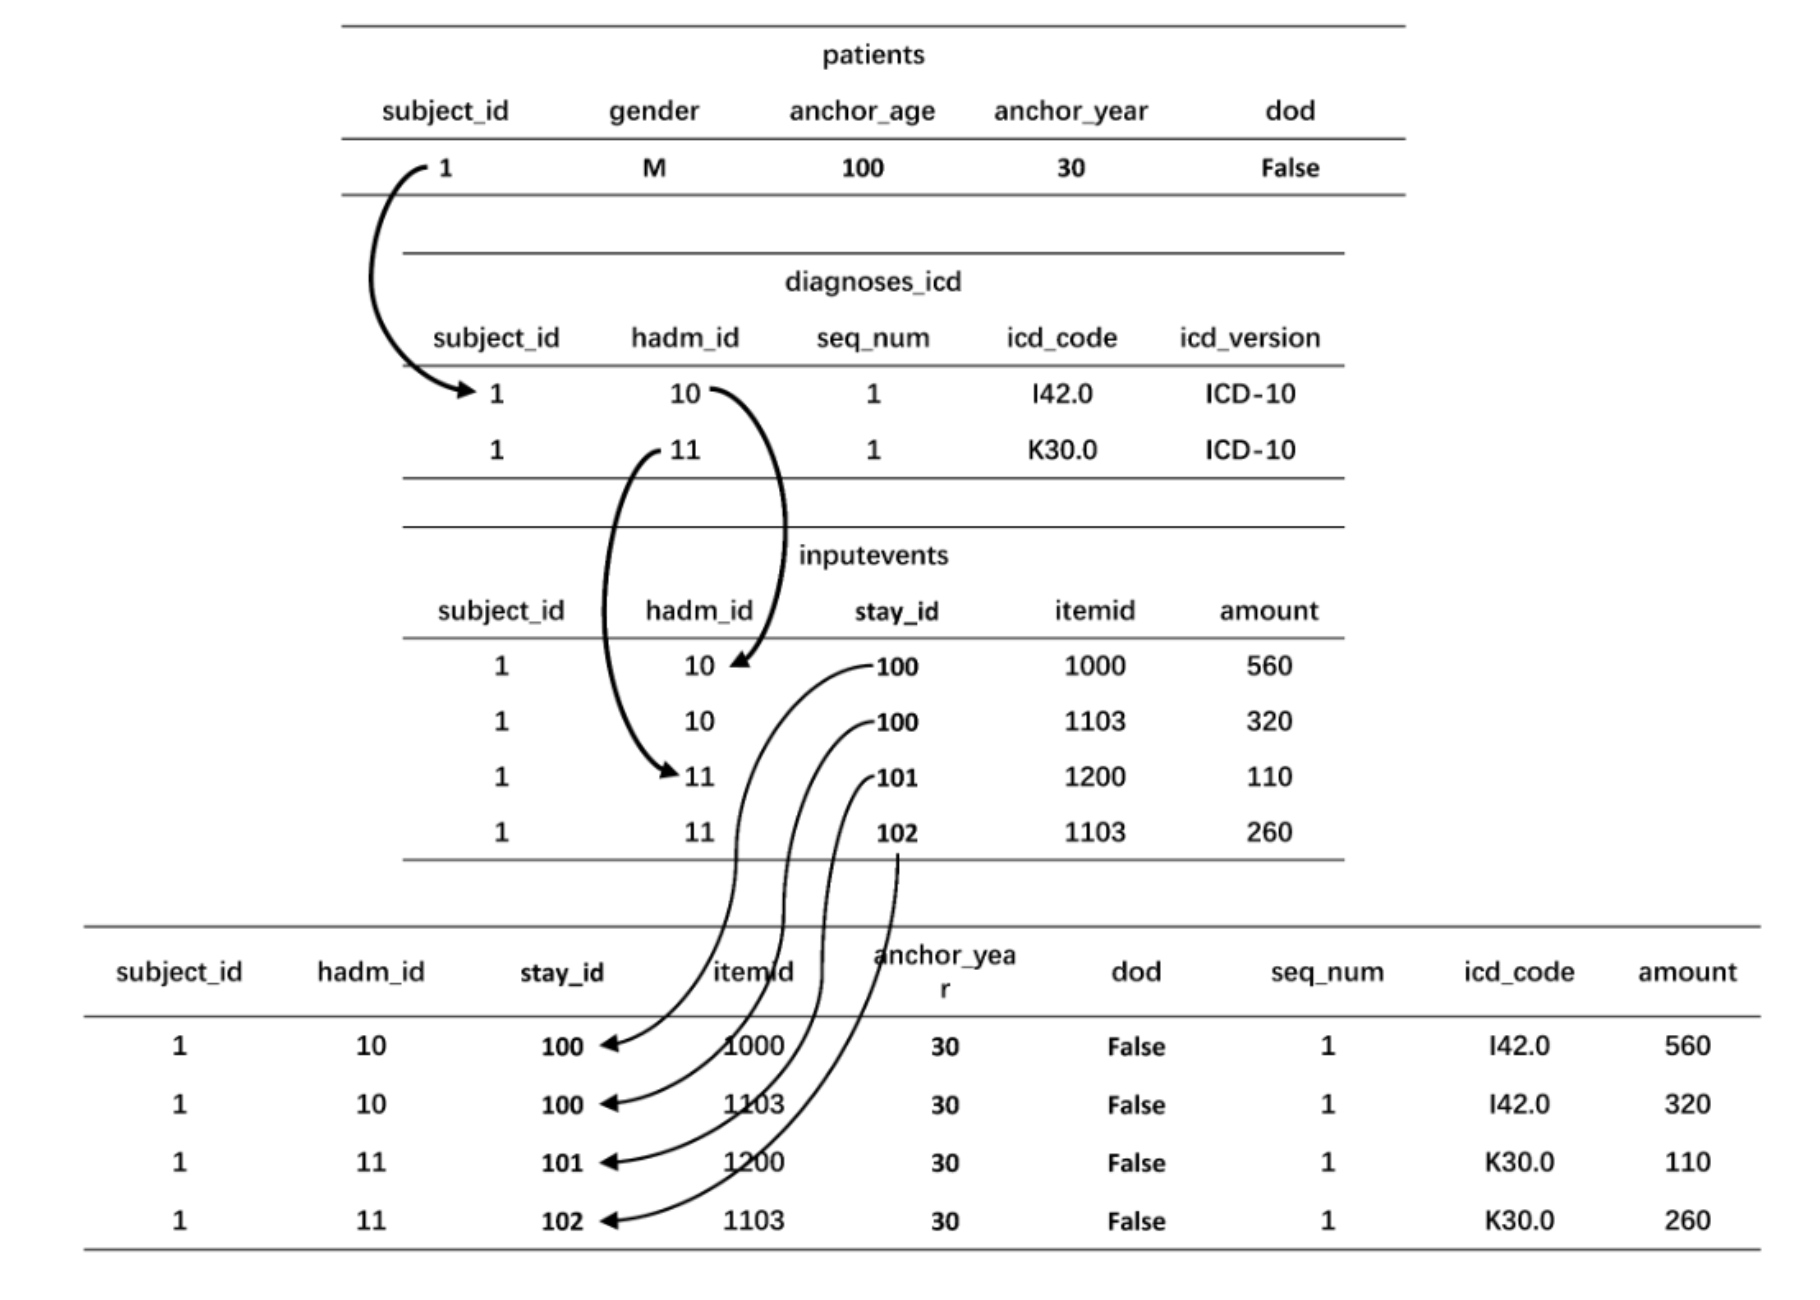


If a patient has multiple admissions at the hospital, we will have multiple hadm_id but only a single subject_id. 

If a  patient has multiple ICU admissions during the same hospital stay, you will have multiple stay_id but a single hadm_id and a unique subject_id.

Before diving into EHR data preprocessing, it is crucial to first obtain an overview of the EHR datasets in order to identify the limitations of their use.  
The complete tutorial notebook for this segment is available [here](https://github.com/celehs/PEHRT/blob/main/TUTORIAL/EHR_Preprocessing_Getting_Started.ipynb).  
To access the full collection of tutorial notebooks, tools, visualizations, and relevant metadata files, please register [here](https://harvard.az1.qualtrics.com/jfe/form/SV_6WJERAowyHA9by6).